Trying different type of models for LST estimation

## General paths, libraries and functions

In [1]:
!pip install seaborn
!pip install statsmodels
!pip install rasterstats


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\guada\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\guada\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\guada\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [1]:
import os
import numpy as np
import rasterio
from rasterio import mask
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import PolynomialFeatures
from rasterstats import zonal_stats
import joblib


In [2]:
# user-defined paths
base_dir = '../../../datos-notebooks/2.global-data-bologna/'
census_areas_name = 'sezioni-di-censimento-anno-2011.geojson'
trained_models_path = '../../../datos-notebooks/1.HR-data-bologna/1.4.LST-prediction/' # modeles trained with HR data

In [6]:
# inputs

# LST
lst_clipped_path = os.path.join(base_dir, 'LST/LST_clipped_celsius.tif') #values out of bound are nan
# vectors
census_areas_path = os.path.join(base_dir, census_areas_name)
# variables - Best results (pearson correlation with LST) for window size -- same as used in HR data
ndwi_1_path = os.path.join(base_dir, 'land-cover/moving-windows/ndwi/Class_1_window61.tif')
ndvi_1_path = os.path.join(base_dir, 'land-cover/moving-windows/ndvi/Class_1_window13.tif')
ndvi_0p5_path = os.path.join(base_dir, 'land-cover/moving-windows/ndvi/Class_0p5_window5.tif')
veg_vol_path = os.path.join(base_dir, 'objects-height/moving-windows/tree-volume/trees_window15.tif')
veg_height_path = os.path.join(base_dir, 'objects-height/moving-windows/tree-height/trees_height_window15.tif')
built_vol_path = os.path.join(base_dir, 'objects-height/moving-windows/building-volume/buildings_window13.tif')
built_area_path = os.path.join(base_dir, 'objects-height/moving-windows/building-area/building_area_window13.tif')
building_height_path = os.path.join(base_dir, 'objects-height/moving-windows/building-height/building_height_window19.tif')
mean_elev_path = os.path.join(base_dir, 'topography/moving_windows/elev_mean/elev_mean_win111.tif')
mean_slope_path = os.path.join(base_dir, 'topography/moving_windows/slope_mean/slope_mean_win19.tif')
northness_path = os.path.join(base_dir, 'topography/moving_windows/northness/northness_win71.tif')


In [7]:
# output directorys
lst_prediction_folder = os.path.join(base_dir, 'LST-prediction/')
os.makedirs(lst_prediction_folder, exist_ok=True)
standarized_folder_path = os.path.join(lst_prediction_folder, 'standarized_variables')

## Dataset preparation

### mask rasters to city boundary

In [8]:
with rasterio.open(lst_clipped_path) as src:
    lst = src.read(1)

lst_mask = np.isnan(lst)

# mask values out of city boundary
ndwi_1 = np.where(lst_mask, np.nan, rasterio.open(ndwi_1_path).read(1).astype("float32"))
ndvi_1 = np.where(lst_mask, np.nan, rasterio.open(ndvi_1_path).read(1).astype("float32"))
ndvi_0p5 = np.where(lst_mask, np.nan, rasterio.open(ndvi_0p5_path).read(1).astype("float32"))
veg_vol = np.where(lst_mask, np.nan, rasterio.open(veg_vol_path).read(1).astype("float32"))
veg_height = np.where(lst_mask, np.nan, rasterio.open(veg_height_path).read(1).astype("float32"))
built_vol = np.where(lst_mask, np.nan, rasterio.open(built_vol_path).read(1).astype("float32"))
built_area = np.where(lst_mask, np.nan, rasterio.open(built_area_path).read(1).astype("float32"))
built_height = np.where(lst_mask, np.nan, rasterio.open(building_height_path).read(1).astype("float32"))
mean_elev = np.where(lst_mask, np.nan, rasterio.open(mean_elev_path).read(1).astype("float32"))
mean_slope = np.where(lst_mask, np.nan, rasterio.open(mean_slope_path).read(1).astype("float32"))
northness = np.where(lst_mask, np.nan, rasterio.open(northness_path).read(1).astype("float32"))

rasters_masked = {
    "Water": ndwi_1,
    "Dense vegetation presence": ndvi_1,
    "Sparse vegetation presence": ndvi_0p5,
    "Vegetation volume": veg_vol,
    "Vegetation height": veg_height,
    "Built volume": built_vol,
    "Built area": built_area,
    "Building height": built_height,
    "Elevation": mean_elev,
    "Slope": mean_slope,
    "Northness": northness
}

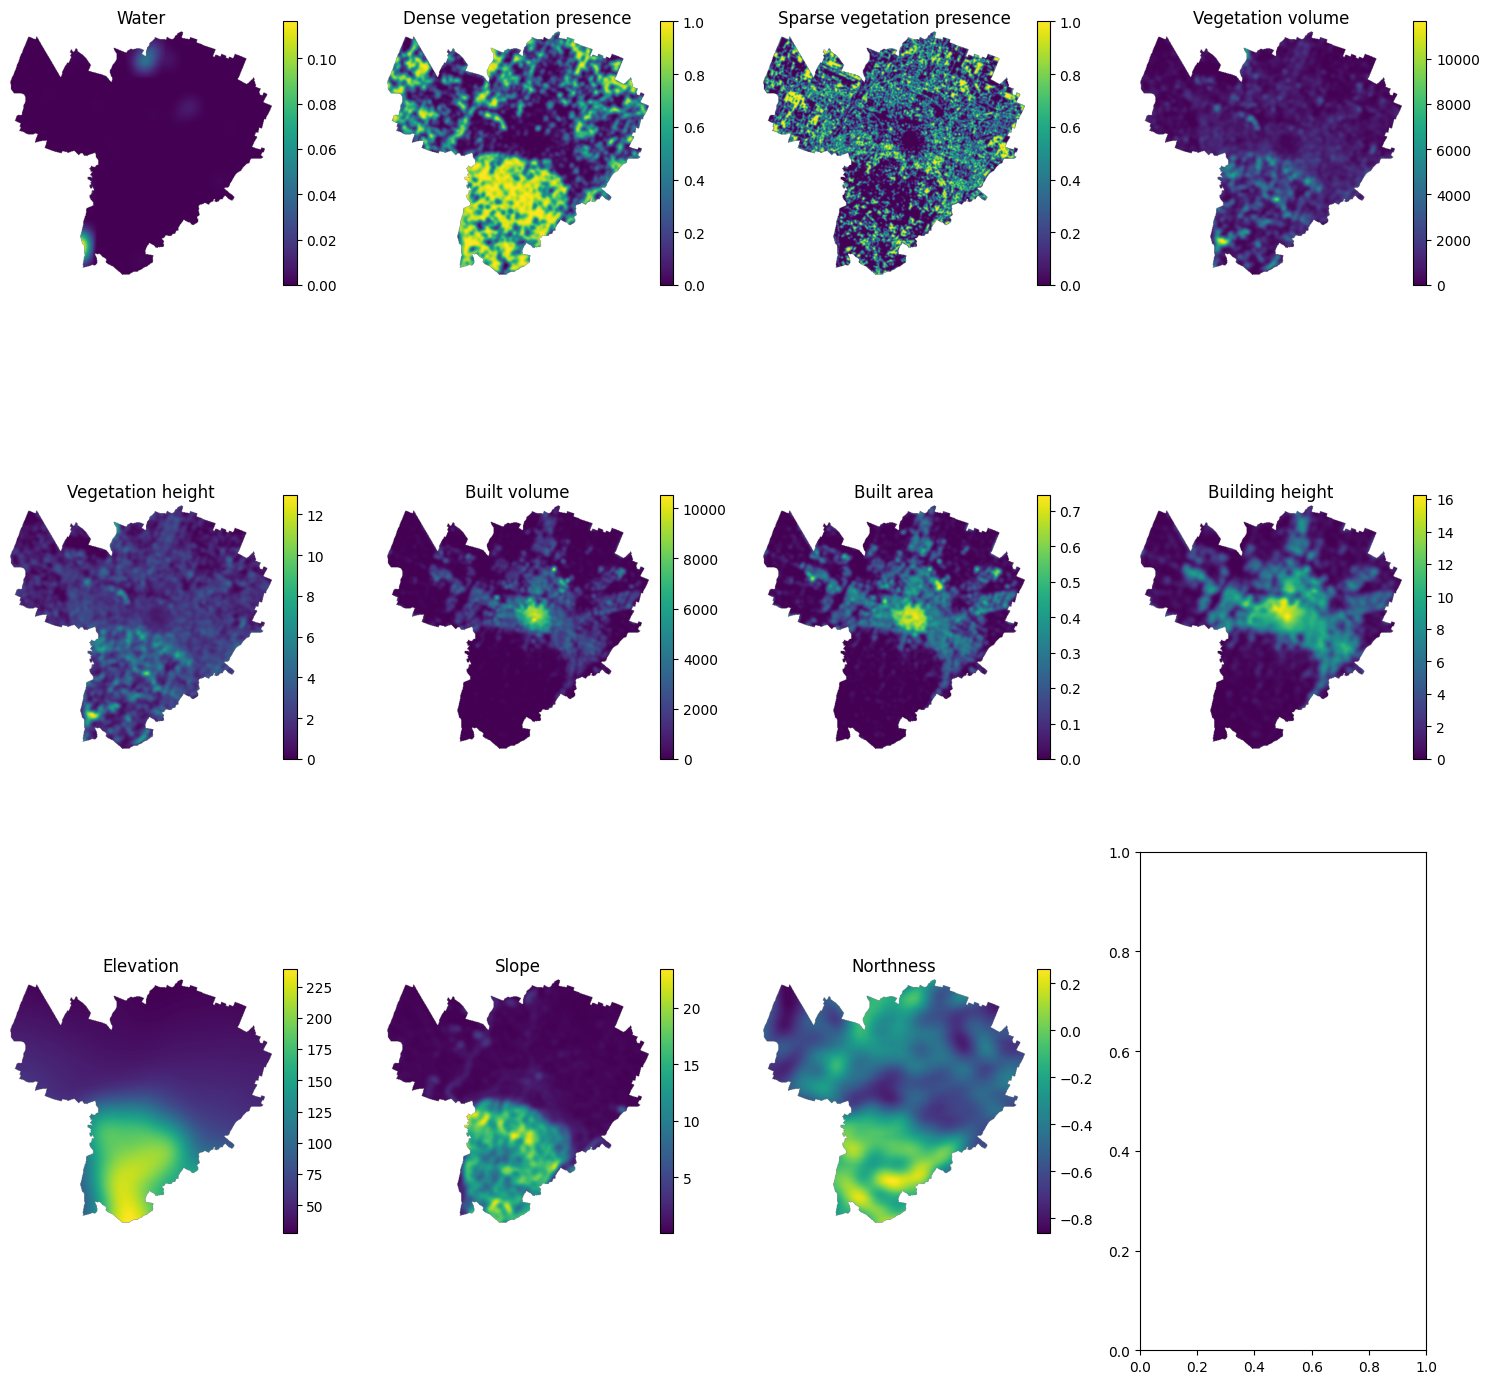

In [9]:
#plot masked rasters 

fig, axes = plt.subplots(3, 4, figsize=(15, 15))

for ax, (name, data) in zip(axes.flat, rasters_masked.items()):

    img = ax.imshow(data, cmap='viridis')
    ax.set_title(name)
    ax.axis('off')
    fig.colorbar(img, ax=ax, fraction=0.046, pad=0.04)


plt.tight_layout()
plt.show()

IndexError: index 10 is out of bounds for axis 0 with size 10

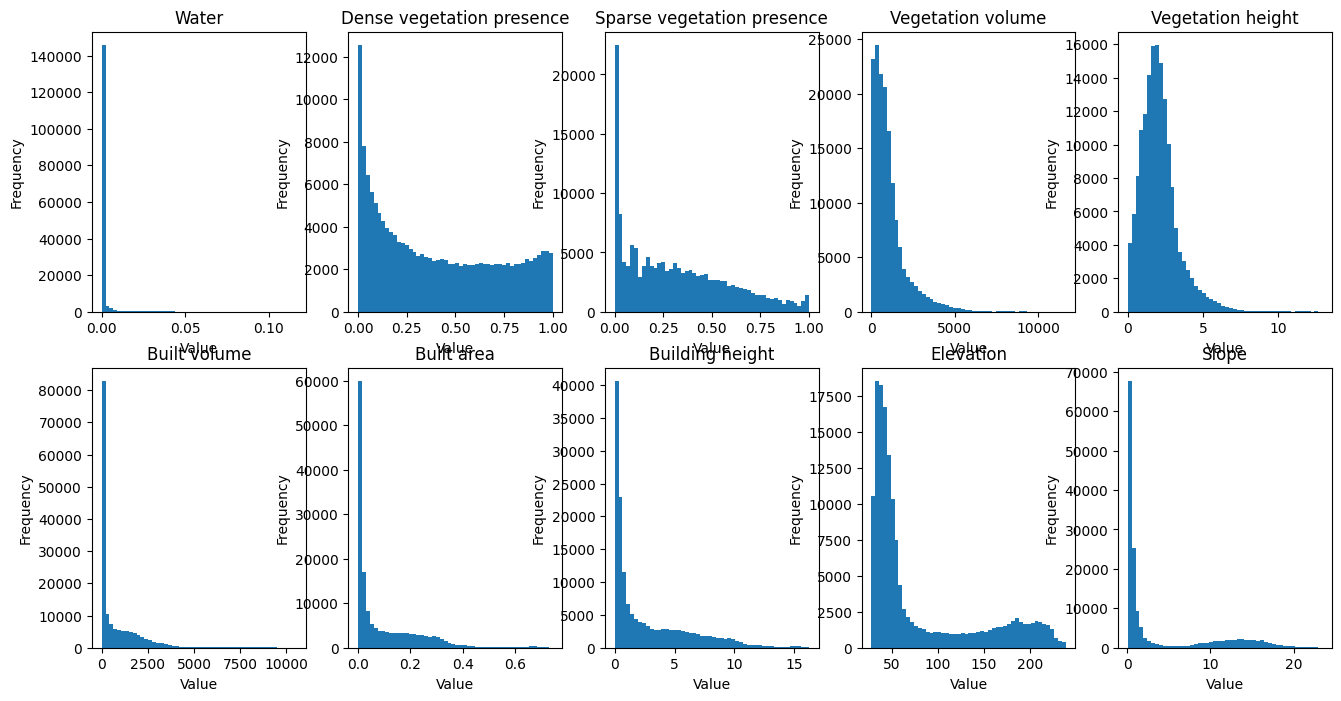

In [10]:
# Plot histograms of masked rasters
fig, axes = plt.subplots(2, 5, figsize=(16, 8))
axes = axes.flatten()  # Flatten to 1D for easy indexing

for i, (name, arr) in enumerate(rasters_masked.items()):
    # Plot histogram using already-masked arrays
    axes[i].hist(arr[~np.isnan(arr)], bins=50)
    axes[i].set_title(name)
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Frequency")

# Hide unused subplots (if less than 8 rasters)
for j in range(i + 1, 8):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

### standarize variables - mean:0, std:1

In [11]:
os.makedirs(standarized_folder_path, exist_ok=True)

In [12]:
# Z-score standardization for regression predictors

def standardize_array(arr, profile, out_path):
    mean = np.nanmean(arr)
    std = np.nanstd(arr)
    z = (arr - mean) / std

    profile.update(dtype='float32')

    with rasterio.open(out_path, 'w', **profile) as dst:
        dst.write(z.astype('float32'), 1)

In [13]:
# Apply standarization
with rasterio.open(lst_clipped_path) as src:
    profile = src.profile.copy()
    
standardize_array(ndwi_1, profile, os.path.join(standarized_folder_path, 'NDWI_1_z.tif'))
standardize_array(ndvi_1, profile, os.path.join(standarized_folder_path, 'NDVI_1_z.tif'))
standardize_array(ndvi_0p5, profile, os.path.join(standarized_folder_path, 'NDVI_0p5_z.tif'))
standardize_array(veg_vol, profile, os.path.join(standarized_folder_path, 'VEG_VOL_z.tif'))
standardize_array(veg_height, profile, os.path.join(standarized_folder_path, 'VEG_HEIGHT_z.tif'))
standardize_array(built_vol, profile, os.path.join(standarized_folder_path, 'BUILT_VOL_z.tif'))
standardize_array(built_area, profile, os.path.join(standarized_folder_path, 'BUILT_AREA_z.tif'))
standardize_array(built_height, profile, os.path.join(standarized_folder_path, 'BUILDING_HEIGHT_z.tif'))
standardize_array(mean_elev, profile, os.path.join(standarized_folder_path, 'ELEV_z.tif'))
standardize_array(mean_slope, profile, os.path.join(standarized_folder_path, 'SLOPE_z.tif'))
standardize_array(northness, profile, os.path.join(standarized_folder_path, 'NORTH_z.tif'))

In [43]:
std_rasters_paths = {
    #"Agua": os.path.join(standarized_folder_path, "NDWI_1_z.tif"),
    "Vegetación densa": os.path.join(standarized_folder_path, "NDVI_1_z.tif"),
    #"Vegetación dispersa": os.path.join(standarized_folder_path, "NDVI_0p5_z.tif"),
    #"Volumen de vegetación": os.path.join(standarized_folder_path, "VEG_VOL_z.tif"),
    #"Volumen construido": os.path.join(standarized_folder_path, "BUILT_VOL_z.tif"),  # Excluido por duplicación de información
    "Área construida": os.path.join(standarized_folder_path, "BUILT_AREA_z.tif"),
    "Altura de edificación": os.path.join(standarized_folder_path, "BUILDING_HEIGHT_z.tif"),
    "Elevación": os.path.join(standarized_folder_path, "ELEV_z.tif"),
    "Pendiente": os.path.join(standarized_folder_path, "SLOPE_z.tif"),
    "Orientación norte": os.path.join(standarized_folder_path, "NORTH_z.tif"),
    "Altura de vegetación": os.path.join(standarized_folder_path, "VEG_HEIGHT_z.tif")    
}

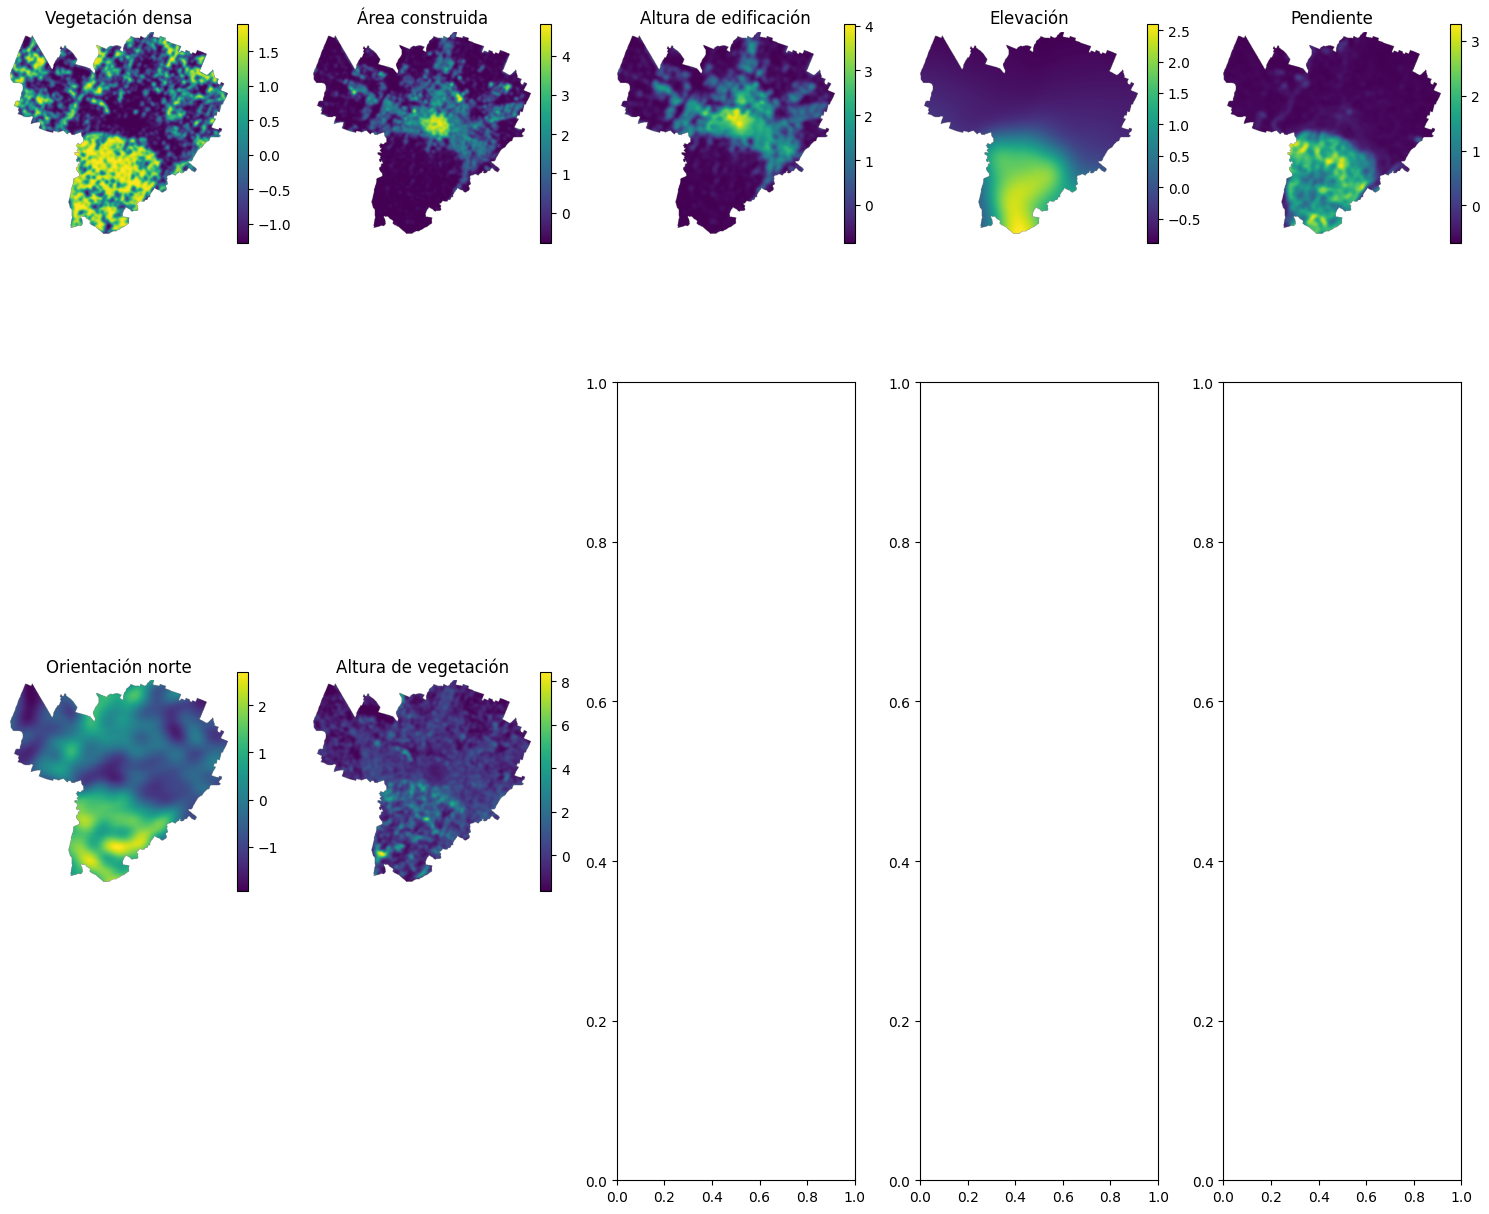

In [44]:
#plot cropped and standardized rasters

fig, axes = plt.subplots(2, 5, figsize=(15, 15))

for ax, (name, path) in zip(axes.flat, std_rasters_paths.items()):
    with rasterio.open(path) as src:
        data = src.read(1).astype(float)

    img = ax.imshow(data, cmap='viridis')
    ax.set_title(name)
    ax.axis('off')
    fig.colorbar(img, ax=ax, fraction=0.046, pad=0.04)


plt.tight_layout()
plt.show()

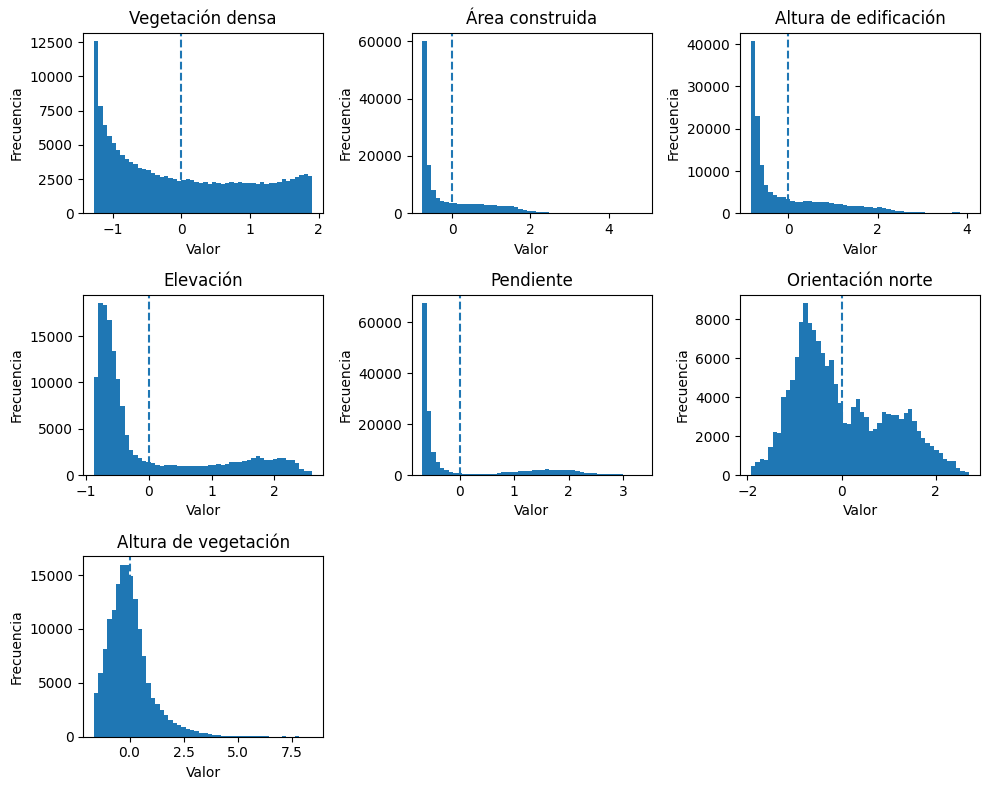

In [54]:

fig, axes = plt.subplots(3, 3, figsize=(10, 8))
axes = axes.flatten()  # Flatten to 1D for easy indexing

for i, (name, path) in enumerate(std_rasters_paths.items()):
    with rasterio.open(path) as src:
        arr = src.read(1).astype("float32")
        nodata = src.nodata

    # Plot histogram
    axes[i].hist(arr[~np.isnan(arr)], bins=50)
    axes[i].set_title(name)
    axes[i].set_xlabel("Valor")
    axes[i].set_ylabel("Frecuencia")
    axes[i].axvline(0, linestyle='--')
    axes[-2].set_visible(False)
    axes[-1].set_visible(False)
    


plt.tight_layout()
plt.show()

### stratified sampling of LST

In [46]:
rasters = {"LST": lst_clipped_path} # create dictionary with LST raster (not standardized)
rasters.update(std_rasters_paths) # add standardized rasters to the dictionary
#rasters.pop("Variable name", None) # to delete one variable if needed

In [47]:
rasters

{'LST': '../../../datos-notebooks/2.global-data-bologna/LST/LST_clipped_celsius.tif',
 'Vegetación densa': '../../../datos-notebooks/2.global-data-bologna/LST-prediction/standarized_variables\\NDVI_1_z.tif',
 'Área construida': '../../../datos-notebooks/2.global-data-bologna/LST-prediction/standarized_variables\\BUILT_AREA_z.tif',
 'Altura de edificación': '../../../datos-notebooks/2.global-data-bologna/LST-prediction/standarized_variables\\BUILDING_HEIGHT_z.tif',
 'Elevación': '../../../datos-notebooks/2.global-data-bologna/LST-prediction/standarized_variables\\ELEV_z.tif',
 'Pendiente': '../../../datos-notebooks/2.global-data-bologna/LST-prediction/standarized_variables\\SLOPE_z.tif',
 'Orientación norte': '../../../datos-notebooks/2.global-data-bologna/LST-prediction/standarized_variables\\NORTH_z.tif',
 'Altura de vegetación': '../../../datos-notebooks/2.global-data-bologna/LST-prediction/standarized_variables\\VEG_HEIGHT_z.tif'}

In [48]:
# Create bins
n_bins = 10

# Read and flatten
data_arrays = {}
for name, path in rasters.items():
    with rasterio.open(path) as src:
        arr = src.read(1)
        data_arrays[name] = arr.flatten()

df = pd.DataFrame(data_arrays)

df = df.dropna() # Drop rows with NaN

df['LST_bin'] = pd.qcut(df['LST'], n_bins, labels=False) # Create LST bins for stratification 

In [49]:
# Stratified sampling: 10% of each bin

sample_fraction = 0.1
df_sampled = df.groupby('LST_bin', group_keys=False).apply(
    lambda x: x.sample(frac=sample_fraction, random_state=42)
)

# Drop bin column
df_sampled = df_sampled.drop(columns=['LST_bin']).reset_index(drop=True)

print(df_sampled.head())


         LST  Vegetación densa  Área construida  Altura de edificación  \
0  33.068665          1.805667        -0.680931              -0.639537   
1  32.350883          1.306578        -0.760521              -0.835348   
2  34.319660          1.170327        -0.606843              -0.519815   
3  32.039841          1.720938        -0.747500              -0.804751   
4  34.459801          1.755697        -0.736775              -0.723235   

   Elevación  Pendiente  Orientación norte  Altura de vegetación  
0   1.053554   2.138849           0.457952              2.041805  
1  -0.807058  -0.331841           1.143459              2.086071  
2   0.793282   1.605314          -0.029866              1.681344  
3   1.135746   2.745764           0.729048              2.027377  
4   2.293686   2.339286           1.542432              0.602306  


C:\Users\guada\AppData\Local\Temp\ipykernel_19256\4163941717.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_sampled = df.groupby('LST_bin', group_keys=False).apply(


In [50]:
# Show min, max and count of LST values in each bin

df_sampled['LST_bin'] = pd.qcut(df_sampled['LST'], n_bins, labels=False) # Recreate bins for the sampled dataset

for b in range(n_bins):
    values_in_bin = df_sampled[df_sampled['LST_bin'] == b]['LST']
    print(f"Bin {b}: min = {values_in_bin.min():.2f}, max = {values_in_bin.max():.2f}, count = {len(values_in_bin)}")

df_sampled = df_sampled.drop(columns=['LST_bin'])

Bin 0: min = 30.58, max = 34.56, count = 1565
Bin 1: min = 34.57, max = 36.29, count = 1565
Bin 2: min = 36.29, max = 37.56, count = 1566
Bin 3: min = 37.57, max = 38.56, count = 1565
Bin 4: min = 38.57, max = 39.43, count = 1564
Bin 5: min = 39.44, max = 40.22, count = 1570
Bin 6: min = 40.22, max = 40.95, count = 1560
Bin 7: min = 40.96, max = 41.74, count = 1566
Bin 8: min = 41.74, max = 42.86, count = 1562
Bin 9: min = 42.86, max = 51.39, count = 1564


### Descriptive statistics

In [51]:
# Split features and target
X = df_sampled.drop(columns=['LST'])
y = df_sampled['LST']

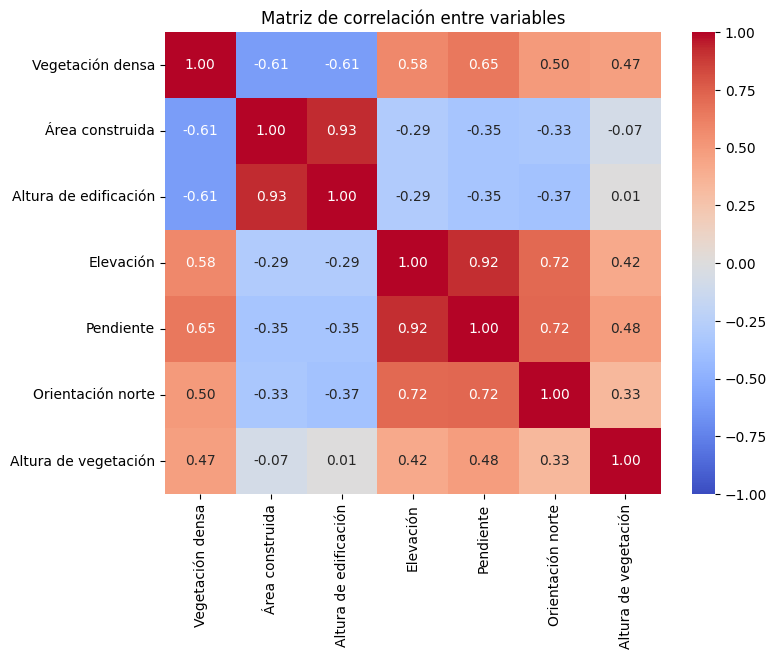

In [52]:
# Compute correlation matrix (only features)
corr_matrix = X.corr()

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Matriz de correlación entre variables")
plt.show()


In [53]:
# Vegetation plot: area vs volume
plt.figure()
plt.scatter(
    df_sampled["Dense veg. presence"],
    df_sampled["Vegetation Volume"],
    s=1, alpha=0.5
)
plt.xlabel("Vegetation presence (z)")
plt.ylabel("Vegetation volume (z)")
plt.title("Vegetation: Area vs Volume")
plt.show()

# Built plot: area vs height
plt.figure()
plt.scatter(
    df_sampled["Built Area"],
    df_sampled["Built Height"],
    s=1, alpha=0.5
)
plt.xlabel("Built area (z)")
plt.ylabel("Built Height (z)")
plt.title("Built: Area vs Height")
plt.show()


KeyError: 'Dense veg. presence'

<Figure size 640x480 with 0 Axes>

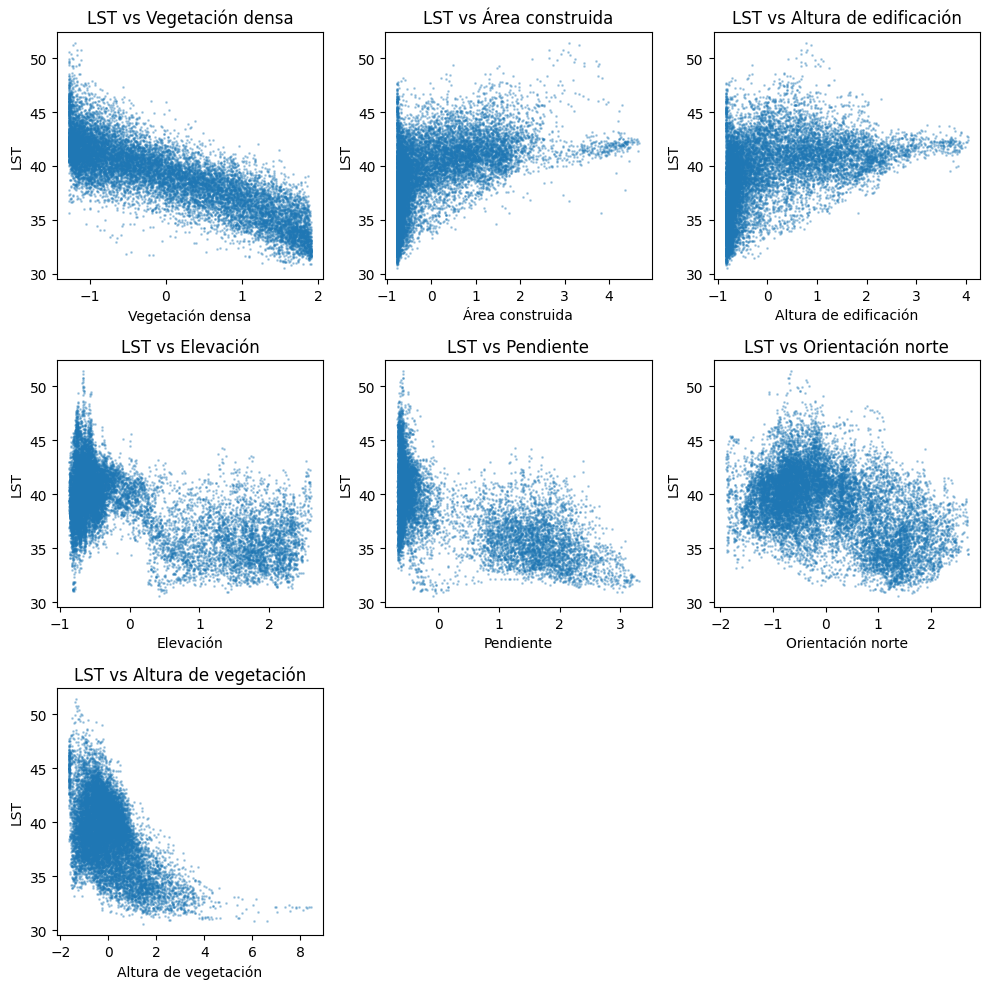

In [55]:
# Plot correlations: Variables vs LST

n_vars = len(X)

fig, axes = plt.subplots(3, 3, figsize=(10, 10))
axes = axes.flatten() 

for i, v in enumerate(X.columns):
    axes[i].scatter(X[v], y, s=1, alpha=0.3)
    axes[i].set_xlabel(v)
    axes[i].set_ylabel("LST")
    axes[i].set_title(f"LST vs {v}")
    axes[-2].set_visible(False)
    axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

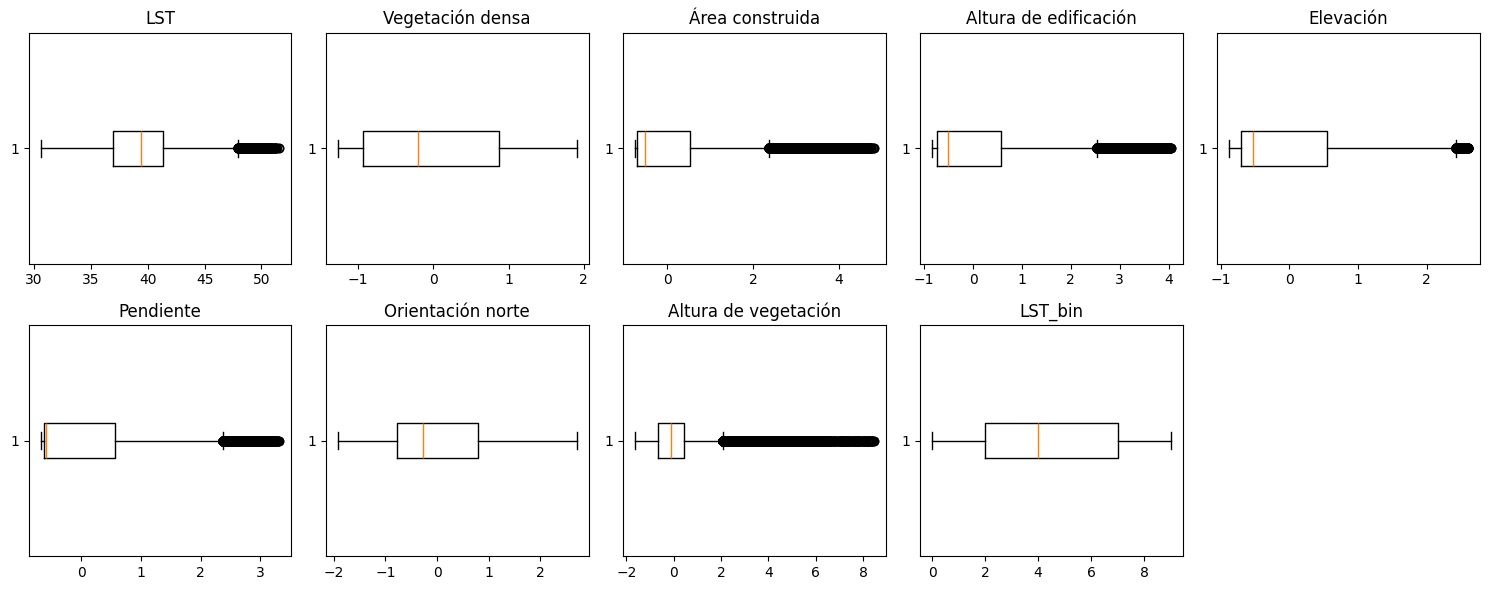

In [64]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i, v in enumerate(df.columns[:10]):
    axes[i].boxplot(df[v], vert=False)
    axes[i].set_title(v)

for ax in axes[len(df.columns):]:
    ax.axis('off')

plt.tight_layout()
plt.show()


### PCA

In [65]:
df_sampled

,LST,Vegetación densa,Área construida,Altura de edificación,Elevación,Pendiente,Orientación norte,Altura de vegetación
0,33.068665,1.805667,-0.680931,-0.639537,1.053554,2.138849,0.457952,2.041805
1,32.350883,1.306578,-0.760521,-0.835348,-0.807058,-0.331841,1.143459,2.086071
2,34.319660,1.170327,-0.606843,-0.519815,0.793282,1.605314,-0.029866,1.681344
3,32.039841,1.720938,-0.747500,-0.804751,1.135746,2.745764,0.729048,2.027377
4,34.459801,1.755697,-0.736775,-0.723235,2.293686,2.339286,1.542432,0.602306
...,...,...,...,...,...,...,...,...
15642,47.526890,-1.163868,2.210074,1.220769,-0.660711,-0.596309,-0.249467,-0.275962
15643,45.455570,-0.961164,1.686359,0.949144,-0.557835,-0.636890,-0.080515,-0.369828
15644,43.203094,-0.775272,0.541591,1.183149,-0.503166,-0.530250,-0.747440,-0.425399
15645,43.404758,-1.222767,1.344526,1.516822,-0.589774,-0.636281,0.132934,-0.203813


In [66]:
y = df_sampled["LST"].values
X = df_sampled.drop(columns=["LST"])

In [67]:
X

,Vegetación densa,Área construida,Altura de edificación,Elevación,Pendiente,Orientación norte,Altura de vegetación
0,1.805667,-0.680931,-0.639537,1.053554,2.138849,0.457952,2.041805
1,1.306578,-0.760521,-0.835348,-0.807058,-0.331841,1.143459,2.086071
2,1.170327,-0.606843,-0.519815,0.793282,1.605314,-0.029866,1.681344
3,1.720938,-0.747500,-0.804751,1.135746,2.745764,0.729048,2.027377
4,1.755697,-0.736775,-0.723235,2.293686,2.339286,1.542432,0.602306
...,...,...,...,...,...,...,...
15642,-1.163868,2.210074,1.220769,-0.660711,-0.596309,-0.249467,-0.275962
15643,-0.961164,1.686359,0.949144,-0.557835,-0.636890,-0.080515,-0.369828
15644,-0.775272,0.541591,1.183149,-0.503166,-0.530250,-0.747440,-0.425399
15645,-1.222767,1.344526,1.516822,-0.589774,-0.636281,0.132934,-0.203813


In [72]:
# Load objects
scaler = joblib.load(os.path.join(trained_models_path, "scaler_pca.pkl"))
pca = joblib.load(os.path.join(trained_models_path, "pca.pkl"))
predictor_names = joblib.load(os.path.join(trained_models_path, "predictor_names_pca.pkl"))

# Apply to new data
X_std = scaler.transform(X)
X_pca = pca.transform(X_std)

ValueError: The feature names should match those that were passed during fit.
Feature names seen at fit time, yet now missing:
- Agua


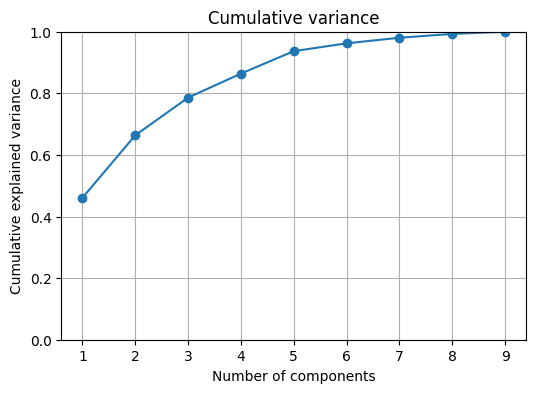

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(np.arange(1, len(pca.explained_variance_ratio_)+1),
         np.cumsum(pca.explained_variance_ratio_), marker="o")
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.ylim(0,1)
plt.title("Cumulative variance")
plt.grid(True)
plt.show()


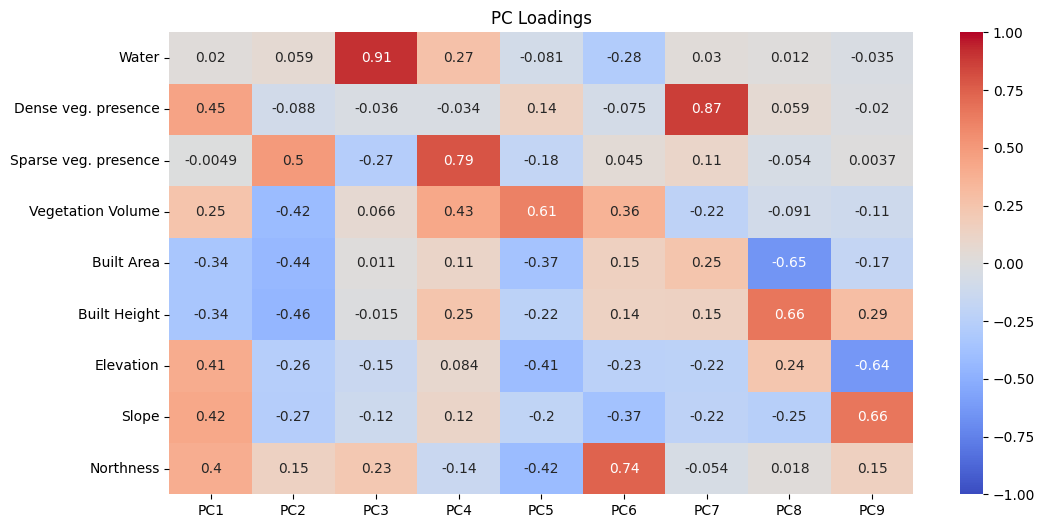

In [ ]:
# Loadings
loadings = pd.DataFrame(
    pca.components_.T,       # each column is a PC
    columns=[f"PC{i+1}" for i in range(X.shape[1])],
    index=predictor_names     # original variable names
)

plt.figure(figsize=(12,6))
sns.heatmap(loadings, annot=True, cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("PC Loadings")
plt.show()


## Different models

### linear regression using PCs

In [ ]:
y = df_sampled["LST"].values
X_pca = pca.transform(X_std)

In [ ]:
# Load model
ols_pcs_model = joblib.load(os.path.join(trained_models_path, "ols_model_pcs.pkl"))

X_new = X_pca[:, :8] # Use already computed PCA

X_new_sm = sm.add_constant(X_new) # Add intercept
y_pred = ols_pcs_model.predict(X_new_sm) # Predict


In [ ]:
# Metrics 
r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))

print(f"R²: {r2:.3f}")
print(f"RMSE: {rmse:.3f}")

R²: 0.702
RMSE: 1.734


### linear regression using PCs + stepwise

In [ ]:
# Load
ols_pcs_stepwise = joblib.load(os.path.join(trained_models_path, "ols_model_pcs_stepwise.pkl"))
selected_pcs = joblib.load(os.path.join(trained_models_path, "selected_pcs_stepwise.pkl"))

X_new = X_pca[:, :8]

# Select same PCs
pc_names = [f"PC{i+1}" for i in range(X_new.shape[1])]
final_idx = [pc_names.index(v) for v in selected_pcs]

X_new_sm = sm.add_constant(X_new)
X_new_final = X_new_sm[:, [0] + [i+1 for i in final_idx]]

# Predict
y_pred = ols_pcs_stepwise.predict(X_new_final)

In [ ]:
# Error metrics with test set
r2_test = r2_score(y, y_pred)
rmse_test = np.sqrt(mean_squared_error(y, y_pred))

print(f"\nTest set R²: {r2_test:.3f}")
print(f"Test set RMSE: {rmse_test:.3f}")



Test set R²: 0.689
Test set RMSE: 1.774


### linear regression using original variables

In [ ]:
X = df_sampled.drop(columns=['LST'])
y = df_sampled['LST']

In [ ]:
# Load model
ols_model = joblib.load(os.path.join(trained_models_path, "ols_model_variables.pkl"))

# Preprocess new data (same X definition)
X_new_sm = sm.add_constant(X)

# Predict
y_pred = ols_model.predict(X_new_sm)


In [ ]:
r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))

print(f"\nTest set R²: {r2:.3f}")
print(f"Test set RMSE: {rmse:.3f}")



Test set R²: 0.696
Test set RMSE: 1.753


### Linear regression using original variables + Stepwise

In [ ]:
X = df_sampled.drop(columns=['LST'])
y = df_sampled['LST']


In [ ]:
# Load
selected_features = joblib.load(
    os.path.join(trained_models_path, "selected_variables_stepwise.pkl")
)
ols_model = joblib.load(
    os.path.join(trained_models_path, "ols_model_variables_stepwise.pkl")
)

# Apply same feature selection
X = df_sampled[selected_features]

# Add intercept
X_new_const = sm.add_constant(X)

# Predict
y_pred = ols_model.predict(X_new_const)

In [ ]:
r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))

print(f"\nTest set R²: {r2:.3f}")
print(f"Test set RMSE: {rmse:.3f}")


Test set R²: 0.695
Test set RMSE: 1.755


### Linear regression using polynomial (grade 2) terms in original variables + stepwise

In [ ]:
X = df_sampled.drop(columns=['LST'])
y = df_sampled['LST']


In [ ]:
# Load
poly = joblib.load(os.path.join(trained_models_path, "poly.pkl"))
selected_poly_features = joblib.load(os.path.join(trained_models_path, "poly_stepwise.pkl"))
ols_poly_model = joblib.load(os.path.join(trained_models_path, "ols_model_poly_stepwise.pkl"))

# Apply same pipeline
X_new_poly = poly.transform(X)

poly_features = poly.get_feature_names_out(X.columns)
X_new_poly_df = pd.DataFrame(X_new_poly, columns=poly_features)

# Select same variables
X_new_sel = sm.add_constant(X_new_poly_df[selected_poly_features])

# Predict
y_pred = ols_poly_model.predict(X_new_sel)

In [ ]:
# Error metrics
r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))

print(f"\nTest set R²: {r2:.3f}")
print(f"Test set RMSE: {rmse:.3f}")


Test set R²: 0.730
Test set RMSE: 1.651


### Random Forest

In [ ]:
df_sampled

,LST,Water,Dense veg. presence,Sparse veg. presence,Vegetation Volume,Built Area,Built Height,Elevation,Slope,Northness
0,33.068665,-0.194622,1.679717,-0.929259,1.889769,-0.655862,-0.623726,1.053554,2.138849,0.354778
1,32.350883,-0.140586,1.046462,-0.879184,2.306296,-0.742308,-0.839327,-0.807058,-0.331841,0.518548
2,34.319660,-0.194622,1.108794,0.374401,1.742971,-0.625225,-0.494780,0.793282,1.605314,0.132555
3,32.039841,-0.194622,1.351369,-0.929259,2.610365,-0.731248,-0.808330,1.135746,2.745764,0.490690
4,34.459801,-0.194622,1.552300,-0.929259,0.521754,-0.729324,-0.718507,2.293686,2.339286,1.988644
...,...,...,...,...,...,...,...,...,...,...
15642,47.526890,0.344421,-1.059871,-0.929259,-0.610908,2.419016,1.233077,-0.660711,-0.596309,-0.531473
15643,45.455570,-0.194622,-0.443133,-0.829110,-0.450469,1.948462,0.836618,-0.557835,-0.636890,-0.794093
15644,43.203094,-0.194622,-0.831109,-0.879184,-0.393881,0.434075,1.276761,-0.503166,-0.530250,-0.721285
15645,43.404758,-0.194622,-1.281065,-0.748405,-0.465387,1.307022,1.468481,-0.589774,-0.636281,-0.069681


##### previously trained model

In [ ]:
# applying to all the city 

# Predictor order (MUST match training)
predictor_order = [
    "Water",
    "Dense veg. presence",
    "Sparse veg. presence",
    "Vegetation Volume",
    "Built Area",
    "Built Height",
    "Elevation",
    "Slope",
    "Northness"
]


# Read rasters using 'rasters' dict
arrays = []
meta = None

for name in predictor_order:
    path = rasters[name]   # get path from existing dict
    with rasterio.open(path) as src:
        arr = src.read(1)
        arrays.append(arr)
        if meta is None:
            meta = src.meta.copy()

stack = np.stack(arrays, axis=-1)  # (rows, cols, n_features)


# Mask nodata pixels
nodata_mask = np.any(np.isnan(stack), axis=-1)


# Reshape for model prediction
nrows, ncols, nbands = stack.shape
X_map = stack.reshape(-1, nbands)

valid = ~nodata_mask.ravel()
X_valid = X_map[valid]

# Predict LST
y_map = np.full(X_map.shape[0], np.nan)   # allocate output
y_map[valid] = rf_model.predict(X_valid) # calls the trained model

# Back to raster shape
lst_pred = y_map.reshape(nrows, ncols)

# Save raster
meta.update(dtype="float32", count=1, nodata=np.nan)

out_path = os.path.join(lst_prediction_folder, "LST_predicted_RF_fromHRdata.tif")

with rasterio.open(out_path, "w", **meta) as dst:
    dst.write(lst_pred.astype("float32"), 1)
    

C:\Users\guada\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [82]:
# applying previously trained model 

X = df_sampled.drop(columns=['LST'])
y = df_sampled['LST']

#  Load previously trained RF model
rf_model = joblib.load(os.path.join(trained_models_path,"rf_model_bologna.pkl"))

# Predict
y_pred = rf_model.predict(X)

# Error metrics
r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))

print(f"R²: {r2:.3f}")
print(f"RMSE: {rmse:.3f}")

ValueError: The feature names should match those that were passed during fit.
Feature names seen at fit time, yet now missing:
- Agua


### new model with this data

In [73]:
X = df_sampled.drop(columns=['LST'])
y = df_sampled['LST']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Random Forest Regressor
rf_model = RandomForestRegressor(
    n_estimators=500,       # number of trees
    max_depth=None,         # no max depth
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)


,n_estimators,500
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [74]:
# Error metrics
y_pred = rf_model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R²: {r2:.3f}")
print(f"RMSE: {rmse:.3f}")

R²: 0.909
RMSE: 0.946


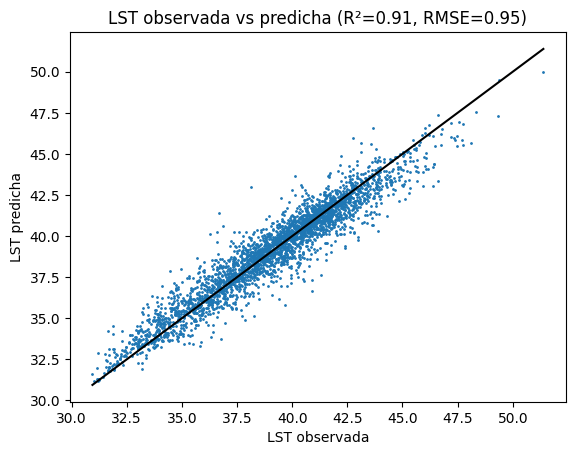

In [83]:
plt.figure()
plt.scatter(y_test, y_pred, s=1)  
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], color="black")
plt.xlabel("LST observada")
plt.ylabel("LST predicha")
plt.title(f"LST observada vs predicha (R²={r2:.2f}, RMSE={rmse:.2f})")
plt.show()

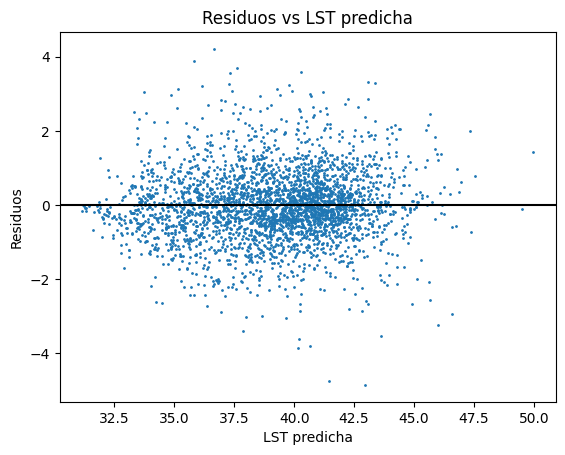

In [85]:
# Residuals plot
residuals = y_test - y_pred

plt.figure()
plt.scatter(y_pred, residuals, s=1)
plt.axhline(0, color='black')
plt.xlabel("LST predicha")
plt.ylabel("Residuos")
plt.title("Residuos vs LST predicha")
plt.show()



In [75]:
# Variable importance
importances = rf_model.feature_importances_

# Create dataframe for sorting
importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": importances
})

# Sort by importance (descending)
importance_df = importance_df.sort_values(by="importance", ascending=False)

# Print ordered results
for _, row in importance_df.iterrows():
    print(f"{row['feature']}: {row['importance']:.3f}")

Vegetación densa: 0.694
Elevación: 0.082
Altura de vegetación: 0.080
Área construida: 0.040
Altura de edificación: 0.039
Orientación norte: 0.037
Pendiente: 0.028


## Applying RF model in all the city

In [76]:
print(X.columns.tolist())


['Vegetación densa', 'Área construida', 'Altura de edificación', 'Elevación', 'Pendiente', 'Orientación norte', 'Altura de vegetación']


In [80]:
# Predictor order (MUST match training)
predictor_order = ['Vegetación densa', 'Área construida', 'Altura de edificación', 'Elevación', 'Pendiente', 'Orientación norte', 'Altura de vegetación']


# Read rasters using 'rasters' dict
arrays = []
meta = None

for name in predictor_order:
    path = rasters[name]   # get path from existing dict
    with rasterio.open(path) as src:
        arr = src.read(1)
        arrays.append(arr)
        if meta is None:
            meta = src.meta.copy()

stack = np.stack(arrays, axis=-1)  # (rows, cols, n_features)


# Mask nodata pixels
nodata_mask = np.any(np.isnan(stack), axis=-1)


# Reshape for model prediction
nrows, ncols, nbands = stack.shape
X_map = stack.reshape(-1, nbands)

valid = ~nodata_mask.ravel()
X_valid = X_map[valid]

# Predict LST
y_map = np.full(X_map.shape[0], np.nan)   # allocate output
y_map[valid] = rf_model.predict(X_valid) # calls the trained model

# Back to raster shape
lst_pred = y_map.reshape(nrows, ncols)

# Save raster
meta.update(dtype="float32", count=1, nodata=np.nan)

out_path = os.path.join(lst_prediction_folder, "LST_predicted_RF.tif")

with rasterio.open(out_path, "w", **meta) as dst:
    dst.write(lst_pred.astype("float32"), 1)
    

C:\Users\guada\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


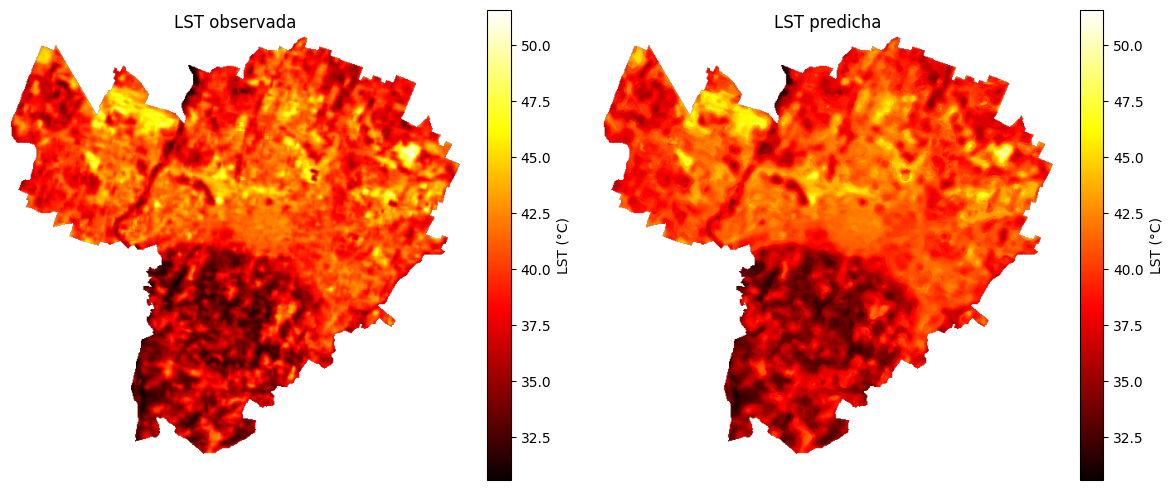

In [86]:
# Plot observed vs predicted LST

lst_predicted_path = os.path.join(lst_prediction_folder, "LST_predicted_RF.tif")

with rasterio.open(lst_clipped_path) as src:
    lst_observed = src.read(1)

with rasterio.open(lst_predicted_path) as src:
    lst_pred = src.read(1)
    
vmin = np.nanmin(lst_observed)
vmax = np.nanmax(lst_observed)

# Plot 
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(lst_observed, vmin=vmin, vmax=vmax, cmap="hot")  # thermal colormap
plt.colorbar(label="LST (°C)")
plt.title("LST observada")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(lst_pred, vmin=vmin, vmax=vmax, cmap="hot")  # same colormap
plt.colorbar(label="LST (°C)")
plt.title("LST predicha")
plt.axis("off")

plt.tight_layout()
plt.show()
